# Customer Churn Prediction - Exploratory Data Analysis

This notebook covers the initial exploratory data analysis (EDA) for the IBM Telco Customer Churn dataset.

## Phase 1: Dataset Analysis

First, we load the dataset and inspect its structure, missing values, and data types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


**Observations:**
- There are 7043 rows and 21 columns.
- `TotalCharges` is an object type, meaning it contains non-numeric strings (like empty spaces ' ') which we need to clean.
- No explicit missing values (NaN) initially, but ' ' in `TotalCharges` acts as missing values.

In [5]:
# Clean TotalCharges for EDA
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df.dropna(inplace=True)

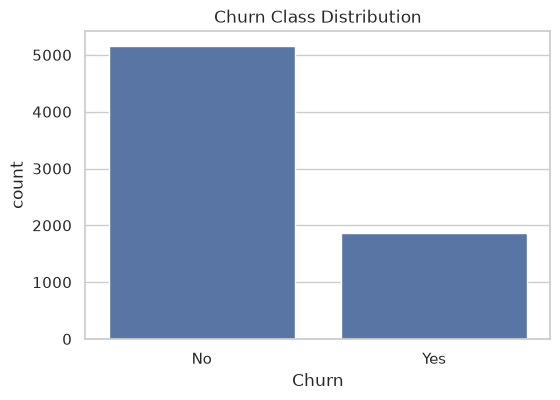

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [6]:
# Churn Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Class Distribution')
plt.show()
print(df['Churn'].value_counts(normalize=True))

**Observation:**
The dataset is imbalanced. About 73% of customers stayed, while 26% churned.

## Phase 2: Exploratory Data Analysis

Let's explore relationships between features and churn.

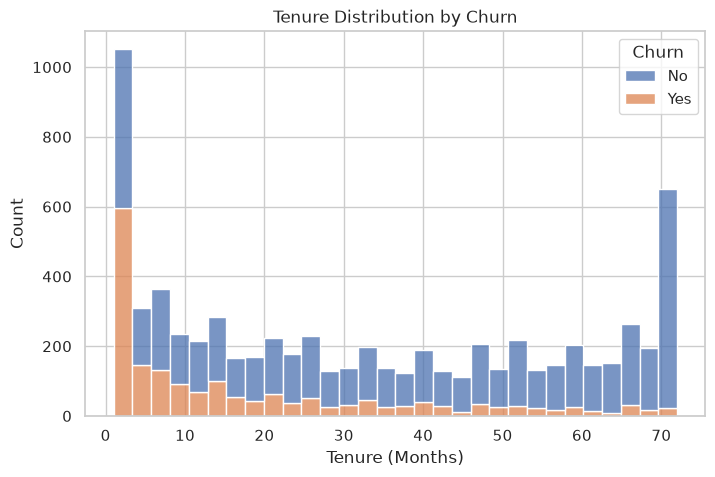

In [7]:
# Tenure vs Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.show()

**Interpretation:** Customers with lower tenure (new customers) are much more likely to churn compared to customers who have been with the company for a long time.

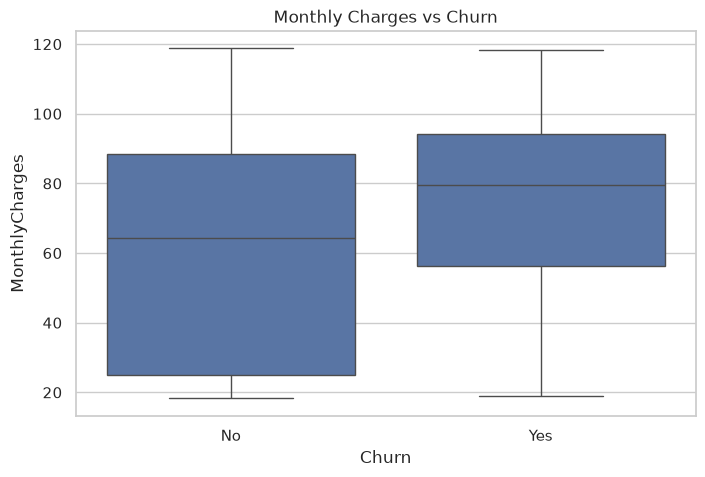

In [8]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.show()

**Interpretation:** Customers who churned tend to have higher monthly charges on average.

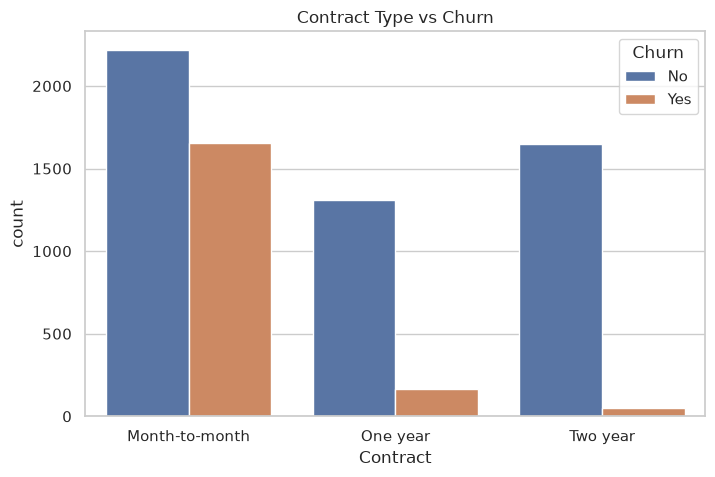

In [7]:
# Contract Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.show()

**Interpretation:** Customers on month-to-month contracts have a significantly higher churn rate compared to those on 1-year or 2-year contracts.

**Interpretation:** Tenure is negatively correlated with churn, while Monthly Charges have a positive correlation with churn.